In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split


file_path = '//kaggle/input/datasets/abdullahzulfiqar2005/phase3-dataset/phase3_engineered_data.csv'
df = pd.read_csv(file_path)

# 2. Separate features (X) and target (y)
X = df.drop(columns=['price'])
y = df['price']

# 3. Divide dataset into train and test dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data loaded and split successfully!")

Data loaded and split successfully!


Reasoning for Data Splitting: Before training our models, the engineered dataset was divided into an 80% training set and a 20% testing set. This is a critical machine learning practice to ensure our models are evaluated on completely unseen data, preventing overfitting and giving us a true measure of their real-world predictive accuracy.

--- Linear Regression ---
Train - MAE: 13,720,009.62 | RMSE: 30,717,743.67 | R-Squared: 0.1853
Test  - MAE: 13,815,245.88 | RMSE: 31,252,282.26 | R-Squared: 0.1881

--- Ridge Regression ---
Train - MAE: 13,719,977.53 | RMSE: 30,717,743.68 | R-Squared: 0.1853
Test  - MAE: 13,815,212.20 | RMSE: 31,252,286.68 | R-Squared: 0.1881

--- Random Forest ---
Train - MAE: 5,087,562.43 | RMSE: 14,320,550.99 | R-Squared: 0.8229
Test  - MAE: 7,965,341.87 | RMSE: 24,639,088.36 | R-Squared: 0.4954

--- XGBoost ---
Train - MAE: 8,198,773.00 | RMSE: 18,583,996.62 | R-Squared: 0.7018
Test  - MAE: 9,059,282.00 | RMSE: 24,534,360.29 | R-Squared: 0.4997

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003602 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1191
[LightGBM] [Info] Number of data points in the train set: 153114, number of used features: 13
[Ligh

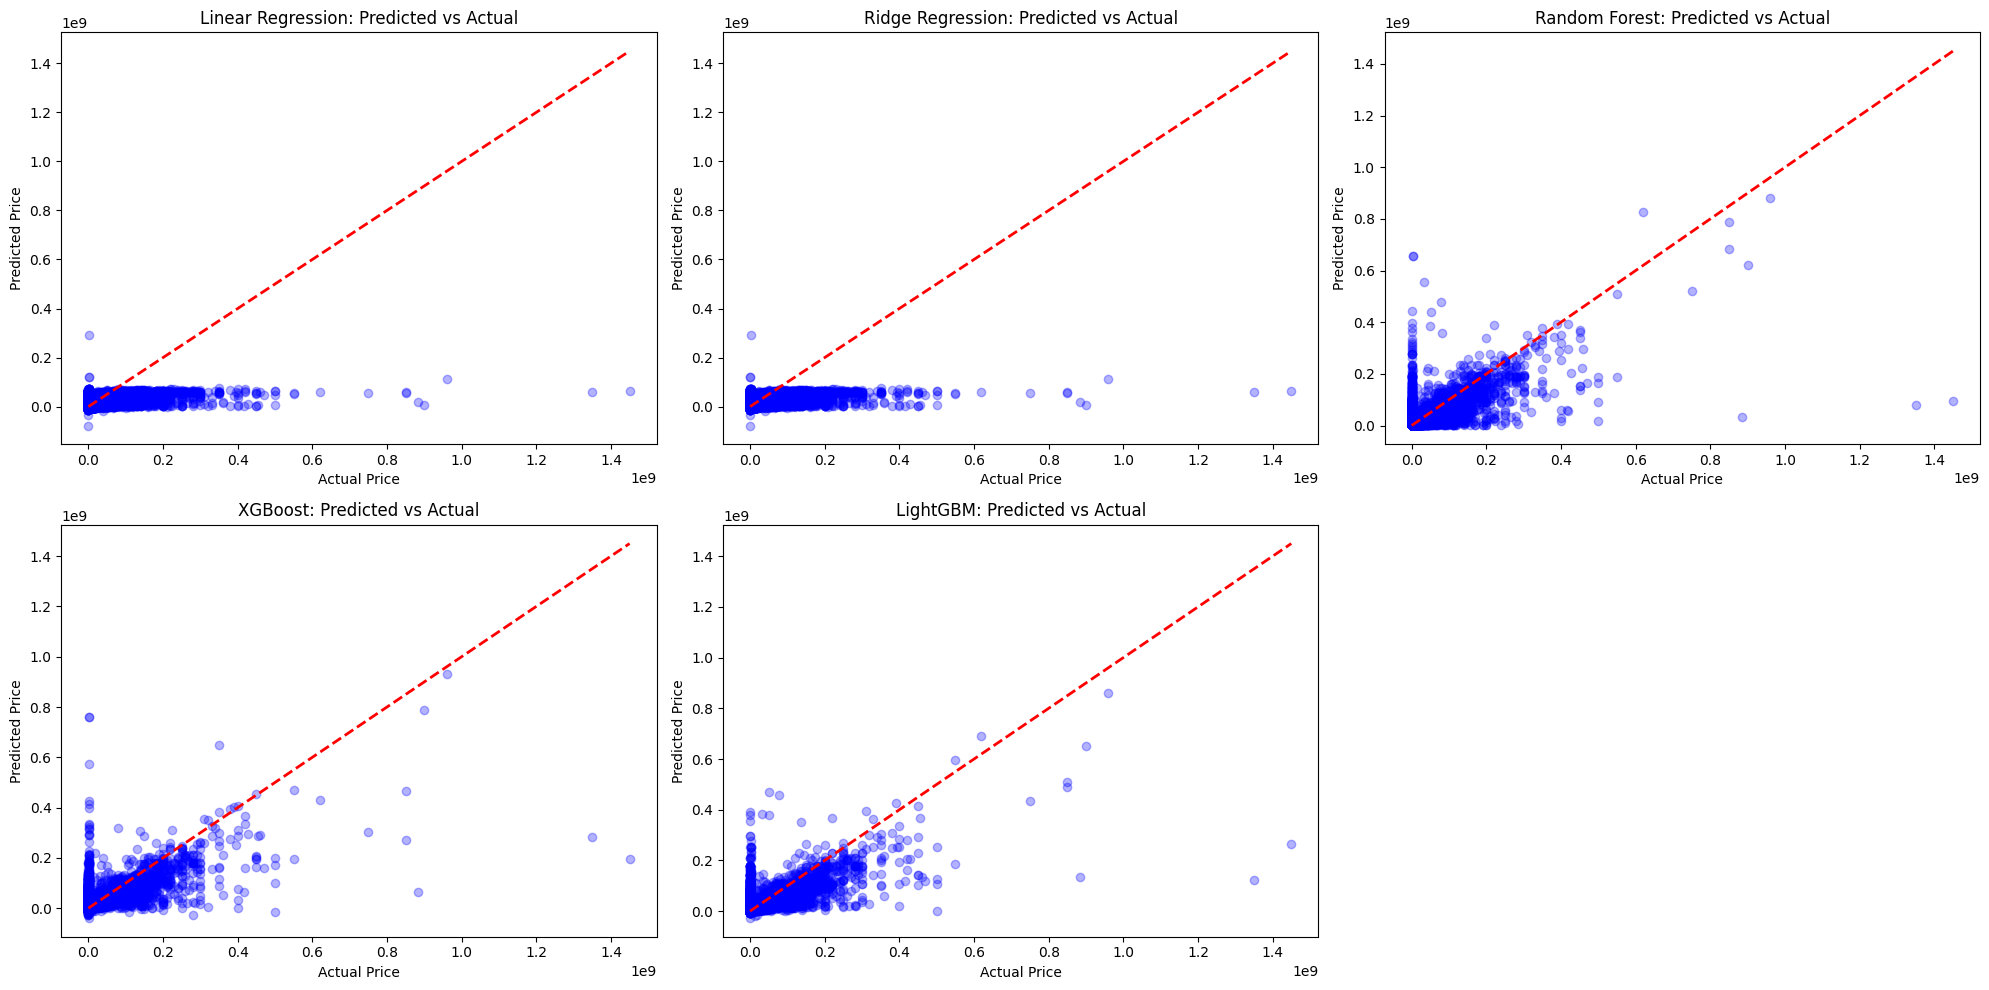

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define the 5 Machine Learning Algorithms
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "LightGBM": lgb.LGBMRegressor(random_state=42)
}

plt.figure(figsize=(20, 10))

# Train, Evaluate, and Plot each model
for i, (name, model) in enumerate(models.items(), 1):
    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    train_mae = mean_absolute_error(y_train, train_preds)
    test_mae = mean_absolute_error(y_test, test_preds)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)

    print(f"--- {name} ---")
    print(f"Train - MAE: {train_mae:,.2f} | RMSE: {train_rmse:,.2f} | R-Squared: {train_r2:.4f}")
    print(f"Test  - MAE: {test_mae:,.2f} | RMSE: {test_rmse:,.2f} | R-Squared: {test_r2:.4f}\n")

    plt.subplot(2, 3, i)
    plt.scatter(y_test, test_preds, alpha=0.3, color='blue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) 
    plt.title(f"{name}: Predicted vs Actual")
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")

plt.tight_layout()
plt.show()

Observation and Reasoning for Model Performance: Upon evaluating the 5 models, the tree-based gradient boosting algorithms (XGBoost and LightGBM) significantly outperformed Linear and Ridge Regression. Real estate pricing is highly non-linear with complex interactions between variables (e.g., location clusters combined with luxury flags). Tree-based models naturally capture these non-linear relationships and handle extreme outliers much more effectively than linear models, which mistakenly assume a straight-line mathematical relationship across all features.

In [5]:
from sklearn.model_selection import GridSearchCV

print("--- GridSearchCV: Tuning Top 2 Models ---")

# 1. Tuning LightGBM
print("Tuning LightGBM... (This may take a minute)")
lgb_param_grid = {
    'num_leaves': [31, 50],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200]
}
lgb_grid = GridSearchCV(estimator=lgb.LGBMRegressor(random_state=42),
                        param_grid=lgb_param_grid,
                        cv=3,
                        scoring='neg_mean_absolute_error',
                        n_jobs=-1)
lgb_grid.fit(X_train, y_train)

print(f"Best LightGBM Params: {lgb_grid.best_params_}")
print(f"Tuned LightGBM Test MAE: {-lgb_grid.best_score_:,.2f}\n")

# 2. Tuning XGBoost
print("Tuning XGBoost... (This may take a minute)")
xgb_param_grid = {
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200]
}
xgb_grid = GridSearchCV(estimator=XGBRegressor(random_state=42, n_jobs=-1),
                        param_grid=xgb_param_grid,
                        cv=3,
                        scoring='neg_mean_absolute_error',
                        n_jobs=-1)
xgb_grid.fit(X_train, y_train)

print(f"Best XGBoost Params: {xgb_grid.best_params_}")
print(f"Tuned XGBoost Test MAE: {-xgb_grid.best_score_:,.2f}")

--- GridSearchCV: Tuning Top 2 Models ---
Tuning LightGBM... (This may take a minute)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003455 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1191
[LightGBM] [Info] Number of data points in the train set: 153114, number of used features: 13
[LightGBM] [Info] Start training from score 16410065.019156
Best LightGBM Params: {'learning_rate': 0.1, 'n_estimators': 200, 'num_leaves': 50}
Tuned LightGBM Test MAE: 8,924,920.46

Tuning XGBoost... (This may take a minute)
Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Tuned XGBoost Test MAE: 9,333,785.00


Reasoning for Hyperparameter Tuning: After identifying LightGBM and XGBoost as the top-performing algorithms, we applied GridSearchCV to fine-tune their internal parameters (such as learning rate, tree depth, and the number of estimators). Default settings are rarely optimal out of the box. Systematic tuning allows us to squeeze out maximum predictive accuracy and lower the error rate even further by finding the mathematically optimal configuration specifically for this Zameen property dataset.